# Predict Beats Per Minute


regression with root mean squre error

## Setup

In [9]:
import pandas as pd


## Load data

In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv
Saving test.csv to test.csv


In [14]:
train_set, test_set = uploaded['train.csv'], uploaded['test.csv']

In [17]:
import io

train_df, test_df = pd.read_csv(io.BytesIO(train_set)), pd.read_csv(io.BytesIO(test_set))
train_df

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511
...,...,...,...,...,...,...,...,...,...,...,...
524159,524159,0.796831,-13.405645,0.023500,0.504738,0.000001,0.191414,0.668079,135528.3189,0.004400,117.83118
524160,524160,0.975000,-12.132914,0.077379,0.069462,0.262320,0.124818,0.288946,240709.3918,0.447067,89.02681
524161,524161,0.542958,-1.357000,0.071390,0.168978,0.000001,0.313912,0.586868,344858.2321,0.718800,90.75885
524162,524162,0.637192,-7.411331,0.113086,0.000005,0.061946,0.287963,0.368891,322710.3187,0.944267,140.63235


## EDA

In [19]:
train_df

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511
...,...,...,...,...,...,...,...,...,...,...,...
524159,524159,0.796831,-13.405645,0.023500,0.504738,0.000001,0.191414,0.668079,135528.3189,0.004400,117.83118
524160,524160,0.975000,-12.132914,0.077379,0.069462,0.262320,0.124818,0.288946,240709.3918,0.447067,89.02681
524161,524161,0.542958,-1.357000,0.071390,0.168978,0.000001,0.313912,0.586868,344858.2321,0.718800,90.75885
524162,524162,0.637192,-7.411331,0.113086,0.000005,0.061946,0.287963,0.368891,322710.3187,0.944267,140.63235


In [22]:
train_df.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [25]:
train_df.describe()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,262081.500000,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,151313.257586,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.000000,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,131040.750000,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,262081.500000,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,393122.250000,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,524163.000000,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'RhythmScore'}>,
        <Axes: title={'center': 'AudioLoudness'}>],
       [<Axes: title={'center': 'VocalContent'}>,
        <Axes: title={'center': 'AcousticQuality'}>,
        <Axes: title={'center': 'InstrumentalScore'}>],
       [<Axes: title={'center': 'LivePerformanceLikelihood'}>,
        <Axes: title={'center': 'MoodScore'}>,
        <Axes: title={'center': 'TrackDurationMs'}>],
       [<Axes: title={'center': 'Energy'}>,
        <Axes: title={'center': 'BeatsPerMinute'}>, <Axes: >]],
      dtype=object)

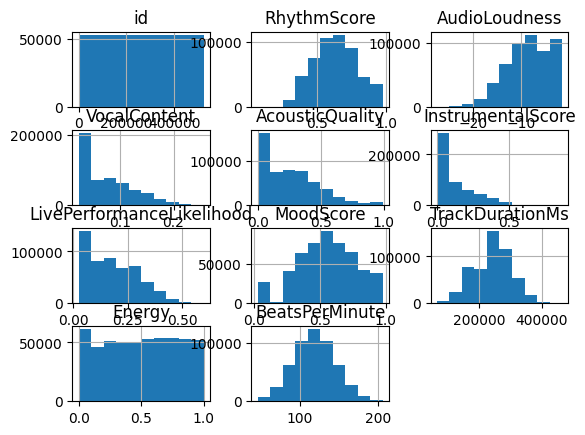

In [27]:
train_df.hist()

### Label

<Axes: >

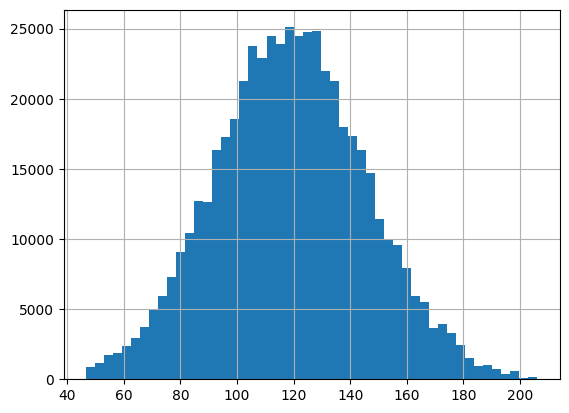

In [55]:
train_df['BeatsPerMinute'].hist(bins=50)
# - fine

In [56]:
train_df.corr(method='spearman')['BeatsPerMinute'].sort_values()

,BeatsPerMinute
Energy,-0.003420
AudioLoudness,-0.002379
id,-0.000882
AcousticQuality,-0.000072
InstrumentalScore,0.002638
VocalContent,0.003559
LivePerformanceLikelihood,0.004368
RhythmScore,0.005916
MoodScore,0.006694
TrackDurationMs,0.006901


### Features

#### RhythmScore

<Axes: >

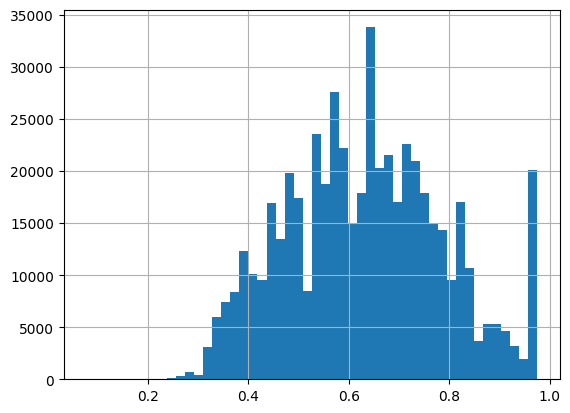

In [52]:
train_df['RhythmScore'].hist(bins=50)
# continuous
# fine for now, can be more uniformly normalized with StandardScaler for linear and NNs

- Unimodal, roughly bell-shaped
- Bounded [0, 1]
- No heavy tails
- No spike at 0 or 1 → not clipped
- Mild unevenness = sampling noise, not a problem

=> **healthy feature**.

In [34]:
train_df['RhythmScore'].describe()

,RhythmScore
count,524164.000000
mean,0.632843
std,0.156899
min,0.076900
25%,0.515850
50%,0.634686
75%,0.739179
max,0.975000


- Scale & range: bounded [0.076900; 0.975000], not need to normalize
- Disctribution shape: mean = median (50%),approx => roughly symmetric, no strong skew
- Variability: moderate spread ( CV (coefficient of variation) = 0.157/0.63=0.25 => 0.1 ≤ CV ≤ 0.3 → moderate spread)
- Outliers? max close to 1, min is not too extreme => no obviouse outlier problem


Outliers:

<Axes: >

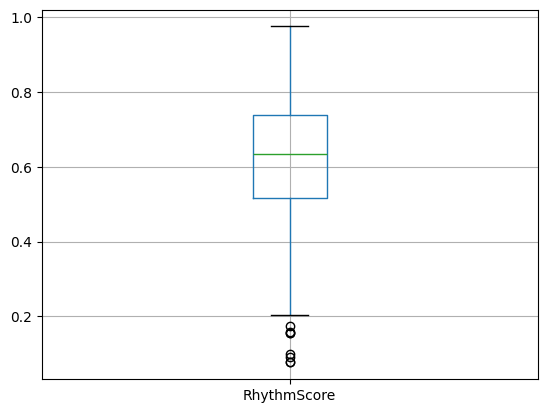

In [35]:
train_df.boxplot('RhythmScore')

- Median ≈ 0.63
- IQR ~ 0.52-0.74 → good spread
- A few low-end outliers (~0.08-0.18)
- Upper end clean (no extreme high outliers)

These “outliers” are valid values, not errors.

In [43]:
Q1 = train_df['RhythmScore'].quantile(0.25)
Q3 = train_df['RhythmScore'].quantile(0.75)
IQR = Q3 - Q1

outliers = train_df[
    (train_df['RhythmScore'] < Q1 - 1.5*IQR) |
    (train_df['RhythmScore'] > Q3 + 1.5*IQR)
]
outliers

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
317326,317326,0.158827,-6.812946,0.023500,0.434630,0.167940,0.107725,0.025600,271491.5754,0.974000,124.44727
368573,368573,0.155926,-6.381575,0.023500,0.044965,0.351720,0.262717,0.025600,238728.5074,0.994000,115.95490
388492,388492,0.155926,-3.538944,0.023500,0.451428,0.227623,0.024300,0.616675,273031.6859,0.955000,104.91968
391345,391345,0.099479,-12.113795,0.023500,0.494568,0.002984,0.134086,0.025600,292775.0856,0.983733,137.06231
404581,404581,0.076900,-16.818981,0.079653,0.000005,0.064712,0.082918,0.639004,243784.2442,0.993600,108.83709
440983,440983,0.174868,-15.037207,0.023500,0.613323,0.000001,0.024300,0.730938,263055.9275,0.513867,125.48969
499041,499041,0.090608,-11.907191,0.023500,0.274945,0.351848,0.300867,0.474038,176710.4545,0.964133,138.52698
515137,515137,0.076900,-12.967227,0.023500,0.000005,0.066012,0.247514,0.737340,293365.0756,0.997800,114.78564


Correlation with target

<Axes: xlabel='RhythmScore', ylabel='BeatsPerMinute'>

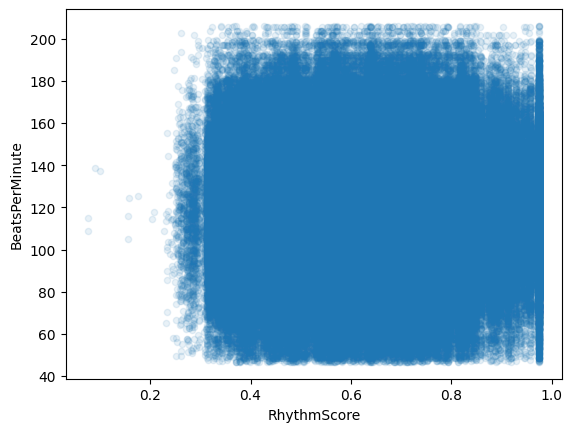

In [54]:
train_df.plot.scatter(x='RhythmScore', y='BeatsPerMinute', alpha=0.1)

- Almost no visible relationship
- BPM spans ~40-200 for all RhythmScore values
- Vertical “wall” → RhythmScore is bounded, BPM is not
- This feature alone cannot predict BPM
- no need for monotonic transforms (log(x), sqrt(x), exp(x), power transforms, rank / quantile transforms)

In [46]:
# Spearman
train_df[['RhythmScore', 'BeatsPerMinute']].corr(method='spearman')

,RhythmScore,BeatsPerMinute
RhythmScore,1.000000,0.005916
BeatsPerMinute,0.005916,1.000000


Conclusion: keep as is for tree based model
Try interactions with other features for linear model

#### AudioLoudness

<Axes: >

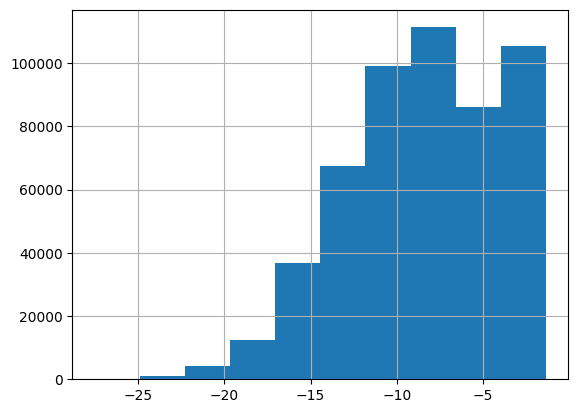

In [33]:
train_df['AudioLoudness'].hist()
# - negative values => sqrt/log is not approriate here since they work on positive values
# Do nothing for tree models
# standardize for linear/ NNs. Standard scaler is fine.